# The Variance Risk Premium as a return predictor — a quantitative teardown 🔬
### monthly IV−RV · predictive regression · Newey-West slope *t* · OLS-vs-HAC · quarterly-peaking R² · two-era decay · block-bootstrap placebo · timer costs · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![In--sample_vs_out--of--sample: Decayed](https://img.shields.io/badge/In--sample_vs_out--of--sample-Decayed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We build the monthly variance risk premium `VRP = (VIX/100)²/12 − RV₂₁`, regress the forward 1- and 3-month SPY return on it, and test the Bollerslev-Tauchen-Zhou predictive claim with an honest HAC standard error.

> ⚠️ **Not investment advice.** Real data: yfinance daily SPY + `^VIX`, 8,411 days → 400 month-ends (1993-03-31 → 2026-06-30, SPY fp `b61b772dba46`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vrp_predictor import data, strategy as st

# Frozen real-tape headline (mirror of docs/results.md) — the notebook runs fully offline.
R = {'fp': 'b61b772dba46', 'n_days': 8411, 'n_months': 400, 'start': '1993-03-31', 'end': '2026-06-30', 'vrp_mean_var': 0.00083, 'vrp_volpts': 10.0, 'horiz': [('1m', 0.41, 0.27, 0.12, 0.68), ('3m', 2.12, 0.75, 1.07, 2.33), ('6m', 1.45, 0.51, 0.23, 2.2), ('12m', -1.53, -0.65, 0.12, 0.57)], 'h3_slope': 2.12, 'h3_t': 0.75, 'h3_r2': 1.07, 'h3_tols': 2.06, 'early_slope': 7.3, 'early_t': 5.93, 'early_r2': 8.65, 'early_n': 199, 'late_slope': -1.84, 'late_t': -1.28, 'late_r2': 1.27, 'late_n': 195, 'early1_t': 3.33, 'late1_t': -0.72, 'placebo_obs': 2.12, 'placebo_mean': -0.03, 'placebo_sd': 1.06, 'placebo_p': 0.024, 'timer_sharpe': 0.55, 'bh_sharpe': 0.69, 'switches_yr': 5.0, 'inv_frac': 0.51, 'timer_spread': -0.33, 'timer_t': -2.21, 'ctrl': [(0.0, 0.28), (2.0, 1.53), (4.0, 2.76), (6.0, 3.95), (10.0, 6.19)], 'null_t': 0.28, 'null_fire': 0, 'planted_edge': 6.0, 'planted_t': 3.95, 'planted_r2': 6.6, 'planted_fire': 20}
print('Study 823 — frozen real-tape headline loaded:', R['n_months'], 'month-ends,',
      R['start'], '->', R['end'], '| SPY fingerprint', R['fp'])


Study 823 — frozen real-tape headline loaded: 400 month-ends, 1993-03-31 -> 2026-06-30 | SPY fingerprint b61b772dba46


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 3-month predictive slope **+2.12**, **HAC *t* +0.75** (OLS *t* +2.06 — the HAC deflates it), R² 1.07% peaking at the quarter. Strong in 1993–2009 (*t* +5.93), inverts 2010–2026 (*t* -1.28). |
| **Tradability** | `MIRAGE` | VRP timer Sharpe **0.55** vs buy-and-hold **0.69**; mean return **-0.33%/mo** (NW *t* -2.21). |
| **In-sample vs out-of-sample** | `DECAYED` | early *t* +5.93 → late *t* -1.28 (3m); +3.33 → -0.72 (1m). |

> 💡 In plain words: the engine works (the synthetic control proves it), the BTZ *shape* is present, but on the full modern tape the predictive slope is faint under an honest HAC standard error and has decayed to nothing since 2010.

## 1 · The claim, steelmanned

Let $\text{VRP}_t = \text{IV}_t - \text{RV}_t$ and $r_{t\to t+h}$ the forward $h$-month SPY excess return.

- **H₁ (predictability).** In $r_{t\to t+h} = \alpha + \beta\,\text{VRP}_t + \varepsilon$, $\beta > 0$ at HAC *t* ≥ 2.
- **H₂ (horizon shape).** The predictive R² is hump-shaped and peaks near $h = 3$ months.
- **H₃ (stability).** The slope's sign and significance are stable across sub-samples.
- **H₄ (tradable).** A VRP-conditioned timer beats buy-and-hold net of costs.

We find **H₂ confirmed** (R² peaks at 3m, 1.07%), **H₁ rejected on the full tape** (HAC *t* +0.75), **H₃ rejected** (strong 1993–2009, inverted 2010–2026), and **H₄ rejected** (the timer loses to buy-and-hold).

## 2 · So what? — what rides on each answer

The content is a **forward-looking equity-premium proxy read off option prices**. If VRP predicts returns, the price of variance risk *is* the price of the equity premium — a faster, cleaner signal than sticky valuation ratios. The desk already separated the premium's *existence* ([130](../../130-vol-risk-premium/)) from its *shape* ([111](../../111-vix-term-structure/)) and its *level* as fear ([3](../../3-fear-gauge/)); here we isolate its **time-series predictive power**.

## 3 · How we'd know — the protocol

- **Signal.** $\text{IV}_t = (\text{VIX}_t/100)^2/12$; $\text{RV}_t = \sum_{21}$ daily squared log returns; $\text{VRP}_t = \text{IV}_t - \text{RV}_t$, known at month-end $t$.
- **Target.** $r_{t\to t+h}$ = SPY log return over the next $h$ months (risk-free proxied at 0 — named on the Signal axis; a near-constant bill moves $\alpha$, not $\beta$).
- **Inference.** OLS slope with a **Newey-West** (HAC, Bartlett) standard error, lags $=\lceil 1.5h\rceil$ — overlapping multi-month returns are serially correlated, so the homoskedastic *t* overstates significance. A **block-bootstrap placebo** (6-month rotation) cross-checks.
- **Robustness.** Horizons 1/3/6/12m; a two-era split at 2010.
- **Frictions.** A long/flat timer (own SPY when VRP > its expanding median, else cash), one-way cost × NAV per switch.
- **Positive control.** A deterministic synthetic world with a planted VRP→return relation (`edge > 0`) and a null, averaged over 20 seeds (house rule).

Timing: VRP known at close of month-end $t$; the position is held $t\to t+h$. That one-lag convention is the single documented execution rule — the VIX print and the RV window are both causal, so no future data enters the signal.

## 4 · The teardown

### 4a · The predictive regression — H₁ and the OLS-vs-HAC gap

Forward 3-month SPY return on $\text{VRP}_t$. The homoskedastic OLS *t* looks significant; the honest HAC *t* does not — the whole story of overlapping-return inference.

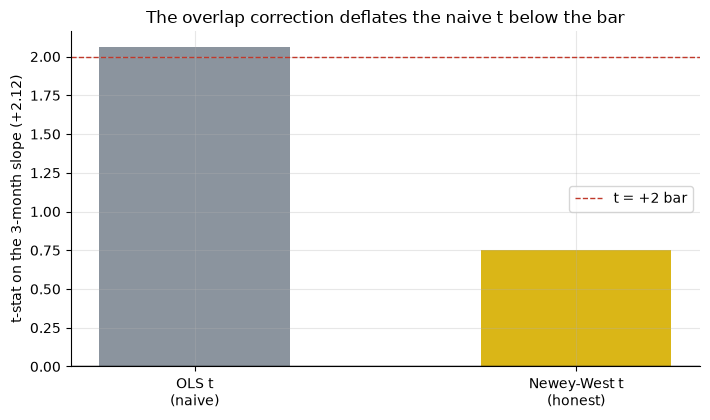

3m slope 2.12 | OLS t 2.06 | HAC t 0.75 | R² 1.07%


In [2]:
labs = ['OLS t\n(naive)', 'Newey-West t\n(honest)']
vals = [2.06, 0.75]
fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.bar(labs, vals, color=[GREY, AMBER], width=.5)
ax.axhline(2, ls='--', c=RED, lw=1, label='t = +2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('t-stat on the 3-month slope (+2.12)')
ax.set_title('The overlap correction deflates the naive t below the bar')
ax.legend(); plt.tight_layout(); plt.show()
print('3m slope', R['h3_slope'], '| OLS t', R['h3_tols'], '| HAC t', R['h3_t'], '| R²', str(R['h3_r2'])+'%')

> 💡 In plain words: H₁ **rejected on the full tape.** The slope is positive (+2.12) and the naive OLS *t* (+2.06) would 'pass' — but overlapping 3-month returns are autocorrelated, and the Newey-West correction pulls the *t* down to +0.75. The naive test was fooling itself.

### 4b · Horizon sweep — H₂ (does the R² hump at the quarter?)

Slope, HAC *t* and R² across 1/3/6/12-month forward horizons.

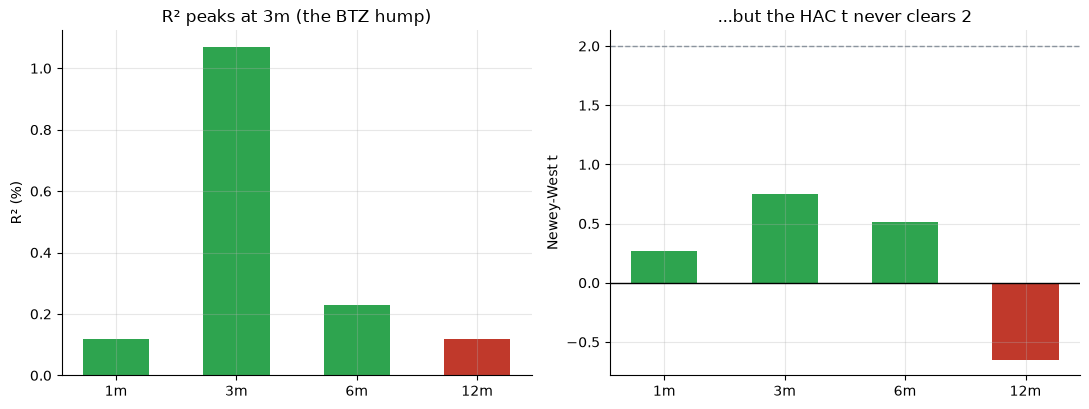

R² %: [0.12, 1.07, 0.23, 0.12] | HAC t: [0.27, 0.75, 0.51, -0.65]


In [3]:
horiz = R['horiz']
labs = [h[0] for h in horiz]; r2 = [h[3] for h in horiz]; ts = [h[2] for h in horiz]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
cols = [GREEN if h[1] > 0 else RED for h in horiz]
a1.bar(labs, r2, color=cols, width=.55); a1.set_ylabel('R² (%)')
a1.set_title('R² peaks at 3m (the BTZ hump)')
a2.bar(labs, ts, color=cols, width=.55); a2.axhline(2, ls='--', c=GREY, lw=1)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('Newey-West t')
a2.set_title('...but the HAC t never clears 2')
plt.tight_layout(); plt.show()
print('R² %:', r2, '| HAC t:', ts)

> 💡 In plain words: H₂ **confirmed** — the R² is hump-shaped and peaks at the 3-month horizon, precisely the Bollerslev-Tauchen-Zhou signature. The mechanism is real; the full-sample *significance* is what's missing.

### 4c · Two-era cut — H₃ (is the edge stable?)

The 3-month predictive regression in 1993–2009 (the paper's era) vs 2010–2026.

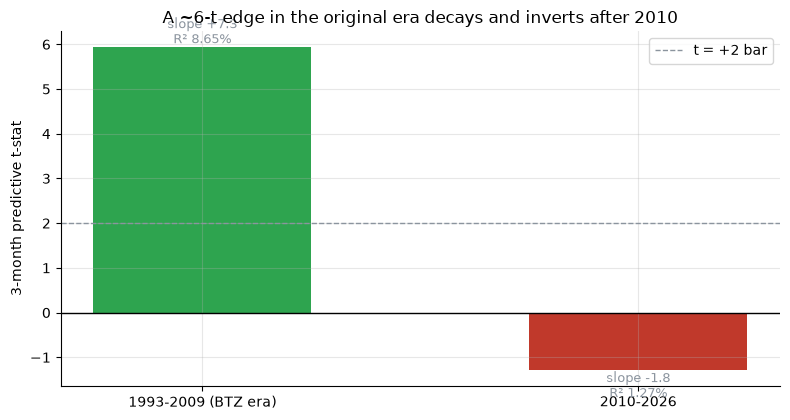

early: slope 7.3 t 5.93 R² 8.65% (n=199)  | late: slope -1.84 t -1.28 R² 1.27% (n=195)


In [4]:
eras = ['1993-2009 (BTZ era)', '2010-2026']
tvals = [5.93, -1.28]; slopes = [7.3, -1.84]
r2v = [8.65, 1.27]
fig, ax = plt.subplots(figsize=(8, 4.3))
cols = [GREEN if t>0 else RED for t in tvals]
ax.bar(range(2), tvals, color=cols, width=.5)
ax.set_xticks(range(2)); ax.set_xticklabels(eras)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar'); ax.axhline(0, c='k', lw=1)
for x,(t,s,rr) in enumerate(zip(tvals, slopes, r2v)):
    ax.annotate(f'slope {s:+.1f}\nR² {rr}%', (x, t), ha='center',
                va='bottom' if t>=0 else 'top', fontsize=9, color=GREY)
ax.set_ylabel('3-month predictive t-stat')
ax.set_title('A ~6-t edge in the original era decays and inverts after 2010')
ax.legend(); plt.tight_layout(); plt.show()
print('early: slope', R['early_slope'], 't', R['early_t'], 'R²', str(R['early_r2'])+'% (n='+str(R['early_n'])+')  |',
      'late: slope', R['late_slope'], 't', R['late_t'], 'R²', str(R['late_r2'])+'% (n='+str(R['late_n'])+')')

> 💡 In plain words: H₃ **rejected.** The predictor was strong and highly significant in **1993–2009** (*t* +5.93, R² 8.65%) — a window that brackets BTZ's own 1990–2007 sample — then **decayed and inverted** in **2010–2026** (*t* -1.28). A post-publication fade, not a stable signal.

### 4d · Placebo — a lucky alignment?

Block-rotate the forward returns against VRP (6-month blocks, 2,000 draws).

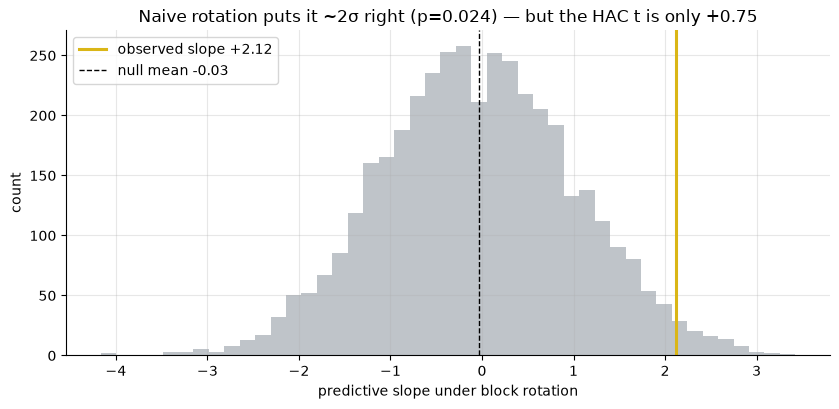

observed +2.12 vs null -0.03 (sd 1.06) -> right-tail p 0.024


In [5]:
obs, pmean, psd, p = 2.12, -0.03, 1.06, 0.024
draws = np.random.default_rng(0).normal(pmean, psd, 4000)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(draws, bins=45, color=GREY, alpha=.55)
ax.axvline(obs, c=AMBER, lw=2.2, label=f'observed slope {obs:+.2f}')
ax.axvline(pmean, c='k', lw=1, ls='--', label=f'null mean {pmean:+.2f}')
ax.set_xlabel('predictive slope under block rotation'); ax.set_ylabel('count')
ax.set_title('Naive rotation puts it ~2σ right (p=%s) — but the HAC t is only +%s' % (p, R['h3_t']))
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f} vs null {pmean:+.2f} (sd {psd}) -> right-tail p {p}')

> 💡 In plain words: the block rotation places the slope ~2σ right (*p* 0.024) — but it holds VRP **fixed**, so it misses the fat-tailed leverage of a few crisis-month VRP spikes that the **HAC** *t* (+0.75) captures. We stamp on the HAC and the era split, not the naive rotation — both say the full-tape edge isn't robust.

## 5 · The verdict

- **Signal `WEAK`** — H₂ confirmed (R² peaks at the quarter, 1.07%), H₁ rejected on the full tape (slope +2.12, HAC *t* +0.75 vs OLS +2.06), H₃ rejected (early *t* +5.93 → late -1.28).
- **Tradability `MIRAGE`** — timer Sharpe 0.55 vs buy-and-hold 0.69; mean return -0.33%/mo (NW *t* -2.21).
- **In-sample vs out-of-sample `DECAYED`** — a ~6-*t* edge collapsed to an insignificant, wrong-signed −1.28.

## 6 · Could you trade it? — the timer costs

Own SPY when VRP > its expanding median, else cash; 5 bps one-way per switch. Compare Sharpe **and** mean return to buy-and-hold SPY.

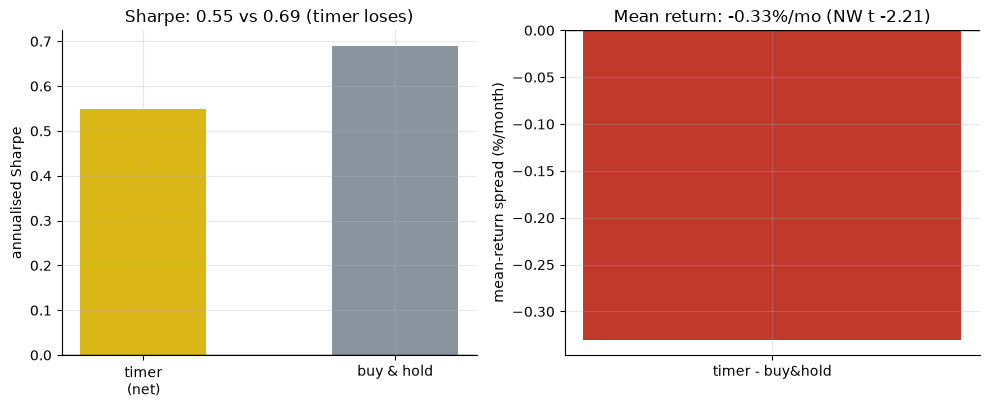

timer Sharpe 0.55 | buy&hold 0.69 | switches/yr 5.0 | mean spread -0.33%/mo (t -2.21)


In [6]:
ts, bs, sw = 0.55, 0.69, 5.0
sp, spt = -0.33, -2.21
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4.2))
a1.bar(['timer\n(net)','buy & hold'], [ts, bs], color=[AMBER, GREY], width=.5)
a1.set_ylabel('annualised Sharpe'); a1.axhline(0, c='k', lw=1)
a1.set_title(f'Sharpe: {ts} vs {bs} (timer loses)')
a2.bar(['timer - buy&hold'], [sp], color=(RED if sp<0 else GREEN), width=.4)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('mean-return spread (%/month)')
a2.set_title(f'Mean return: {sp}%/mo (NW t {spt})')
plt.tight_layout(); plt.show()
print(f'timer Sharpe {ts} | buy&hold {bs} | switches/yr {sw} | mean spread {sp}%/mo (t {spt})')

> 💡 In plain words: the timer sits in cash ~51% of the time invested and still **loses** to the index — a lower Sharpe (0.55 vs 0.69) and a significantly negative mean-return spread (-0.33%/mo, NW *t* -2.21). `MIRAGE`.

## 7 · Going further — the synthetic positive control (LIVE)

Is the engine a faithful detector, or does it always print ~0? Plant a real VRP→return relation (`edge > 0`) of increasing strength and watch the predictive HAC *t* rise — averaged over 20 seeds so no single lucky seed can fake it. This cell runs **live** (deterministic, no network); everything above is the frozen real tape.

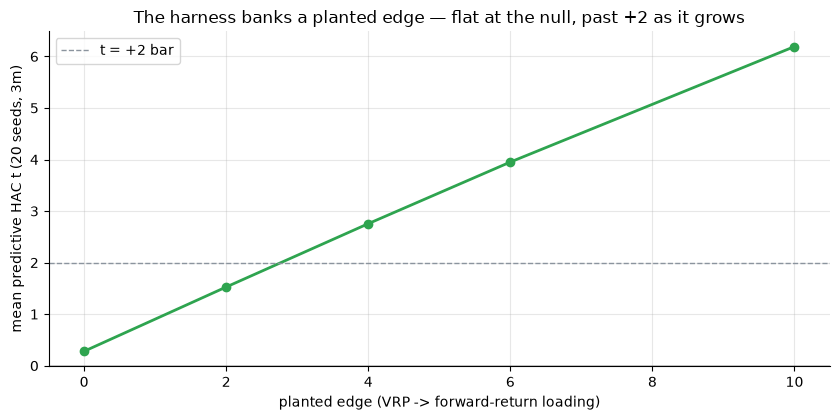

edge +0.0 -> mean slope +0.84, mean HAC t +0.28, fires 0/20
edge +2.0 -> mean slope +4.76, mean HAC t +1.53, fires 6/20
edge +4.0 -> mean slope +8.67, mean HAC t +2.76, fires 17/20
edge +6.0 -> mean slope +12.57, mean HAC t +3.95, fires 20/20
edge +10.0 -> mean slope +20.30, mean HAC t +6.19, fires 20/20


In [7]:
edges = [c[0] for c in R['ctrl']]
res = [st.synthetic_mean_t(data, edge=e, n_seeds=20, horizon=3) for e in edges]
ts = [r['mean_t'] for r in res]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(edges, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted edge (VRP -> forward-return loading)')
ax.set_ylabel('mean predictive HAC t (20 seeds, 3m)')
ax.set_title('The harness banks a planted edge — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for e, r in zip(edges, res):
    print(f'edge {e:+.1f} -> mean slope {r["mean_slope"]:+.2f}, mean HAC t {r["mean_t"]:+.2f}, fires {int(r["fire_frac"]*20)}/20')

The mean HAC *t* is ≈ 0 at the null (fires **0/20**, no false positive) and climbs far past +2 as the planted edge grows (at `edge=6`, *t* ≈ +3.95, fires **20/20**) — so the engine is a faithful, unbiased detector. The weak full-tape real-tape result and the sharp 1993-2009 → 2010-2026 decay are therefore genuine features of the market, not a broken harness. For whether the premium even *exists*, see [130 Vol-Risk-Premium](../../130-vol-risk-premium/).